In [14]:
import pandas as pd
import numpy as np
import sys
sys.path.append("/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline/")
from SynOmics.processing.preprocessing import DataProcessor
from SynOmics.processing.metadata import MetaData

clinical_data = pd.read_csv("MelanomaData/clinical_data.csv")
omics_data = pd.read_csv("MelanomaData/TranscriptomicsData.csv")
clinical_data = clinical_data.rename(columns={"Unnamed: 0": "Patient"})
omics_data = omics_data.rename(columns={"Unnamed: 0": "Patient"})

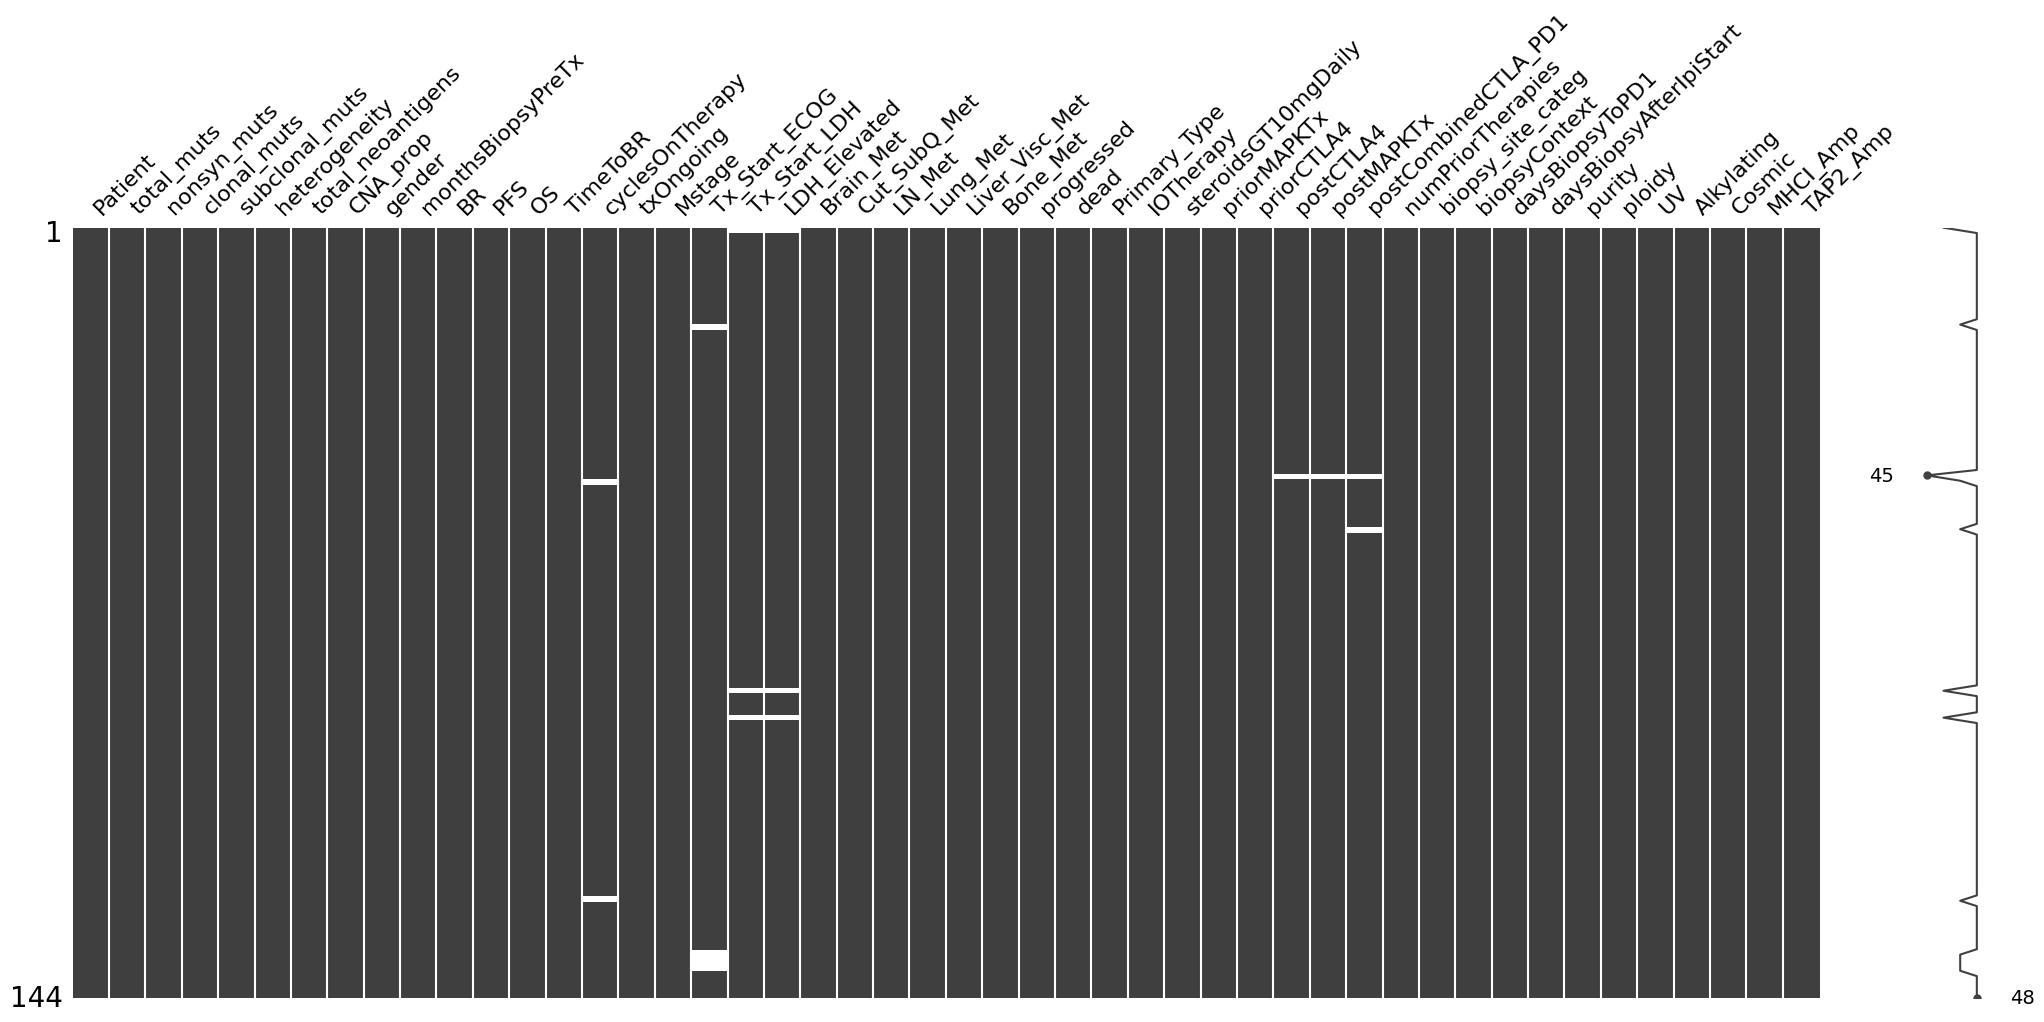

In [15]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(clinical_data)
    
# Adjust layout and show
plt.tight_layout(h_pad=3)
plt.show()

In [16]:
import pandas as pd
from SynOmics.processing.pipeline import DataIntegrationPipeline


# Set output directory for logs/metadata
output_dir = "./Integration_MelanomaData"

# Optional: define imputation hyperparameters for MICE or KNN
# For MICE (miceforest, if available):
imputer = "mice"
imputer_params = {
    "iterations": 10,
    "n_estimators": 100,
    "random_state": 42
}


# Known ordinal categorical columns in clinical data
ordinal_cat_columns = ["BR", "Mstage", "Tx_Start_ECOG",
                       "numPriorTherapies","biopsyContext"]

# Steps config (optional, defaults to all True)
steps_config = {
    "remove_undefined": True,
    "remove_duplicates": True,
    "remove_overmissing_samples": True,
    "check_duplicate_genes": True,
    "mapping_genes": False,
    "feature_engineering": True,
    "integrate_data": True
}

# Create and run the pipeline
pipeline = DataIntegrationPipeline(output_dir=output_dir, logger="Integration_Melanoma")

results = pipeline.run_pipeline(
    clinical_data=clinical_data,
    transcriptomics_data=omics_data,
    clinical_id_column="Patient",
    transcriptomics_id_column="Patient",
    integration_id_column="Patient",
    steps_config=steps_config,
    overmissing_samples_threshold=30,      # percent
    overmissing_features_threshold=30,     # percent
    unique_threshold=10,
    scaler="minmax",
    ordinal_cat_columns=ordinal_cat_columns,
    imputer=imputer,
    imputer_params=imputer_params,
    add_indicators=True,
    verbose=True,
)

2025-11-21 16:38:58 - DEBUG - Standalone logger initialized successfully.
2025-11-21 16:38:58 - INFO - === STARTING DATA INTEGRATION PIPELINE ===
2025-11-21 16:38:58 - INFO - [CONFIG] Steps: {'remove_undefined': True, 'remove_duplicates': True, 'remove_overmissing_samples': True, 'check_duplicate_genes': True, 'mapping_genes': False, 'feature_engineering': True, 'integrate_data': True}
2025-11-21 16:38:58 - DEBUG - Standalone logger initialized successfully.
2025-11-21 16:38:58 - INFO - [TRANSCRIPTOMICS] Initial shape: rows=121, cols=18761
2025-11-21 16:38:58 - INFO - [T1] Removing undefined samples missing ID in 'Patient'
2025-11-21 16:38:58 - INFO - [T1] Removed 0 rows; new shape: rows=121, cols=18761 (took 0.01s)
2025-11-21 16:38:58 - INFO - [T2.1] Removing duplicate columns
2025-11-21 16:38:58 - INFO - [T2.1] Removed 0 duplicate columns; cols=18761 (took 0.01s)
2025-11-21 16:38:58 - INFO - [T2.2] Removing duplicate rows
2025-11-21 16:39:00 - INFO - [T2.2] Removed 0 duplicate rows; 

In [17]:
integrated_data = results["integrated_data"]
processed_clinical = results["processed_clinical"]
processed_omics = results["processed_transcriptomics"]

#Save dataframes

integrated_data.to_csv("Integration_MelanomaData/integrated_data_melanoma.csv", index = False)
processed_clinical.to_csv("Integration_MelanomaData/processed_clinical_melanoma.csv", index = False)
processed_omics.to_csv("Integration_MelanomaData/processed_transcriptomics_melanoma.csv", index = False)